# Inspect one raw battery JSON file

**Purpose (Week 1):** Open a single cell file with `json.load`, see what fields exist, and make a few plots — **without** processing all 140 files.

**You will learn:**
- How Python reads a `.json` file into a nested dictionary
- The difference between **per-cycle summary** (small table) and **interpolated curves** (large arrays)
- Which columns you can export later for machine learning

## 0. Setup paths

This notebook lives in `notebooks/`. Raw data is in `data/raw/`. We move up one folder so paths work.

In [1]:
import os
from pathlib import Path

# If your kernel starts in notebooks/, go to project root
if Path.cwd().name == 'notebooks':
    os.chdir('..')

PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
print('Project root:', PROJECT_ROOT)
print('Raw data dir:', RAW_DIR)

Project root: C:\gnem-battery-degradation
Raw data dir: C:\gnem-battery-degradation\data\raw


## 1. Pick one file and load it with `json.load`

`json.load(file)` reads the whole file and returns a **Python dictionary** (`dict`).
- Keys are strings (e.g. `'barcode'`, `'summary'`)
- Values can be numbers, lists, or more nested dicts

We only load **one** file here so this notebook stays fast (seconds, not minutes).

In [2]:
import json
import glob

files = sorted(glob.glob(str(RAW_DIR / 'FastCharge*.json')))
print(f'Found {len(files)} JSON files in data/raw/')

sample_path = files[0]  # change index to try another cell
print('Inspecting:', sample_path)

with open(sample_path, 'r', encoding='utf-8') as f:
    cell = json.load(f)

print('Loaded successfully. Top-level type:', type(cell))

Found 140 JSON files in data/raw/
Inspecting: C:\gnem-battery-degradation\data\raw\FastCharge_000000_CH19_structure.json
Loaded successfully. Top-level type: <class 'dict'>


## 2. Top-level keys — what is inside one cell file?

Think of this as the "table of contents" for one battery.

In [3]:
print('Top-level keys:')
for key in cell.keys():
    value = cell[key]
    if isinstance(value, dict):
        detail = f'dict with {len(value)} keys'
    elif isinstance(value, list):
        detail = f'list, length {len(value)}'
    else:
        detail = repr(value)[:80]
    print(f'  {key:25} -> {detail}')

Top-level keys:
  @module                   -> 'beep.structure'
  @class                    -> 'ProcessedCyclerRun'
  barcode                   -> 'el150800440551'
  protocol                  -> '2017-06-30_tests\\20170630-4_4C_55per_6C.sdu'
  channel_id                -> 18
  summary                   -> dict with 16 keys
  cycles_interpolated       -> dict with 8 keys
  diagnostic_summary        -> None
  diagnostic_interpolated   -> None
  @version                  -> '2020.10.19.20-8667111'


In [4]:
print('Cell barcode (ID):', cell.get('barcode'))
print('Channel:', cell.get('channel_id'))
print('Protocol:', cell.get('protocol'))

Cell barcode (ID): el150800440551
Channel: 18
Protocol: 2017-06-30_tests\20170630-4_4C_55per_6C.sdu


## 3. Per-cycle `summary` — your main table for Week 1–2

In these files, `summary` is a **dictionary of columns**:
- Each key is a column name (e.g. `discharge_capacity`)
- Each value is a **list** with one entry per cycle

We turn that into a pandas DataFrame: **one row per cycle**.

In [5]:
import pandas as pd

summary = pd.DataFrame(cell['summary'])
print('Shape (rows, columns):', summary.shape)
print('\nColumn names:')
print(list(summary.columns))

Shape (rows, columns): (491, 16)

Column names:
['cycle_index', 'discharge_capacity', 'charge_capacity', 'discharge_energy', 'charge_energy', 'dc_internal_resistance', 'temperature_maximum', 'temperature_average', 'temperature_minimum', 'date_time_iso', 'energy_efficiency', 'charge_throughput', 'energy_throughput', 'charge_duration', 'time_temperature_integrated', 'paused']


In [6]:
print('First 5 cycles:')
display(summary.head())

print('\nNumeric summary (quick sanity check):')
display(summary.describe())

First 5 cycles:


,cycle_index,discharge_capacity,charge_capacity,discharge_energy,charge_energy,dc_internal_resistance,temperature_maximum,temperature_average,temperature_minimum,date_time_iso,energy_efficiency,charge_throughput,energy_throughput,charge_duration,time_temperature_integrated,paused
0,0,1.934572,1.417352,6.116106,4.673017,0.029384,34.168961,30.977694,25.237902,2017-07-01T03:52:32+00:00,1.308813,1.417352,4.673017,33280.0,39217.381470,0
1,1,1.045426,1.045648,3.173665,3.646161,0.017864,34.850071,32.641014,30.334539,2017-07-02T00:59:44+00:00,0.870413,2.463000,8.319178,640.0,1936.503715,0
2,2,1.048037,1.048442,3.176155,3.651186,0.017929,34.573605,32.274544,29.808897,2017-07-02T01:59:28+00:00,0.869897,3.511442,11.970364,640.0,1915.932650,0
3,3,1.048029,1.047885,3.175840,3.651785,0.018012,34.393002,32.078480,30.053253,2017-07-02T02:59:12+00:00,0.869668,4.559327,15.622149,640.0,1974.178617,0
4,4,1.049100,1.049186,3.182562,3.653328,0.017671,34.299545,32.473103,30.322723,2017-07-02T04:01:04+00:00,0.871140,5.608512,19.275476,512.0,1930.615568,0



Numeric summary (quick sanity check):


,cycle_index,discharge_capacity,charge_capacity,discharge_energy,charge_energy,dc_internal_resistance,temperature_maximum,temperature_average,temperature_minimum,energy_efficiency,charge_throughput,energy_throughput,charge_duration,time_temperature_integrated,paused
count,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,463.000000,491.000000,491.0
mean,245.000000,0.990931,0.990338,2.929511,3.466431,0.017753,36.078125,32.689065,30.190274,0.843951,250.511415,874.717706,745.883369,1989.273146,0.0
std,141.883755,0.067183,0.054776,0.244402,0.173948,0.001182,0.844748,0.307049,0.516094,0.027614,141.423570,494.908981,1518.797489,1818.972774,0.0
min,0.000000,0.823668,0.826335,2.336979,2.927123,0.016435,33.860344,30.977694,25.237902,0.798388,1.417352,4.673017,512.000000,1665.629887,0.0
25%,122.500000,0.967491,0.967999,2.825485,3.397491,0.016942,35.539854,32.498547,29.913065,0.832484,128.819641,448.663879,640.000000,1822.839524,0.0
50%,245.000000,1.002036,1.002182,2.959777,3.506080,0.017390,36.050892,32.695457,30.226683,0.844366,253.159256,883.170044,640.000000,1886.443571,0.0
75%,367.500000,1.027759,1.027915,3.075367,3.587497,0.018173,36.671789,32.891737,30.547546,0.857145,374.034424,1306.579834,640.000000,1932.020054,0.0
max,490.000000,1.934572,1.417352,6.116106,4.673017,0.029384,38.611477,33.615402,31.406075,1.308813,486.255859,1702.017822,33280.000000,39217.381470,0.0


### What each summary column is (for your dataset description doc)

| Column | Meaning |
|--------|--------|
| `cycle_index` | Cycle number |
| `discharge_capacity` | How much charge delivered on discharge (Ah) |
| `charge_capacity` | Charge capacity (Ah) |
| `dc_internal_resistance` | DC internal resistance |
| `temperature_maximum` / `average` / `minimum` | Temperature stats that cycle |
| `energy_efficiency` | Energy efficiency |
| `charge_duration` | How long charging took |

Copy this table into `docs/week01/dataset_description.md` and adjust if your columns differ on another file.

## 4. Simple plot — capacity fade for this one cell

This is the same kind of curve you will use in Week 2 figures.

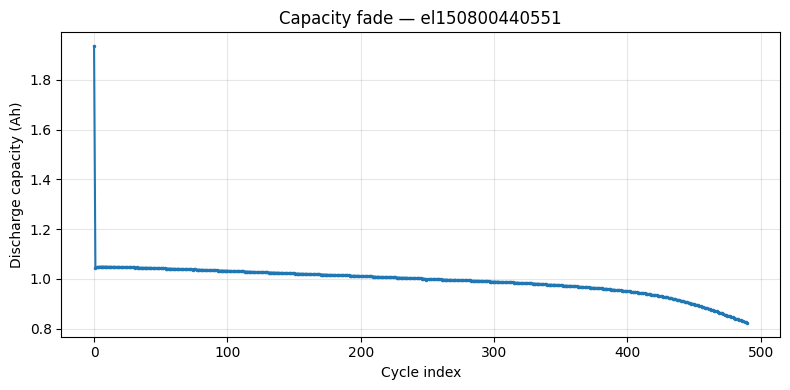

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(summary['cycle_index'], summary['discharge_capacity'], marker='.', markersize=3)
ax.set_xlabel('Cycle index')
ax.set_ylabel('Discharge capacity (Ah)')
ax.set_title(f"Capacity fade — {cell.get('barcode')}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. EOL check on this one cell (80% of first cycle capacity)

This matches the logic in `01_data_exploration.ipynb`. We use cycles with `cycle_index >= 1` to skip index 0 if needed.

Initial capacity (cycle >= 1): 1.0454 Ah
80% threshold: 0.8363 Ah
EOL cycle index: 484


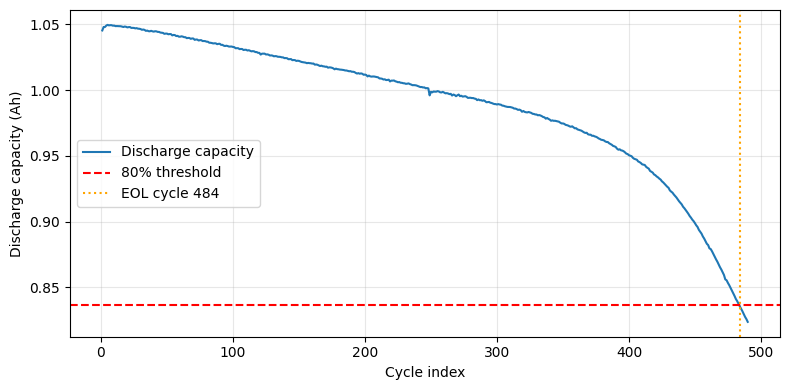

In [8]:
s = summary[summary['cycle_index'] >= 1].copy()
initial_cap = s['discharge_capacity'].iloc[0]
threshold = 0.8 * initial_cap

below = s[s['discharge_capacity'] < threshold]
eol = below.iloc[0]['cycle_index'] if len(below) > 0 else s['cycle_index'].iloc[-1]

print(f'Initial capacity (cycle >= 1): {initial_cap:.4f} Ah')
print(f'80% threshold: {threshold:.4f} Ah')
print(f'EOL cycle index: {eol}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(s['cycle_index'], s['discharge_capacity'], label='Discharge capacity')
ax.axhline(threshold, color='red', linestyle='--', label='80% threshold')
ax.axvline(eol, color='orange', linestyle=':', label=f'EOL cycle {eol}')
ax.set_xlabel('Cycle index')
ax.set_ylabel('Discharge capacity (Ah)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. `cycles_interpolated` — voltage / current (large arrays)

These files store **interpolated** time-series data in long format:
- `cycle_index`, `voltage`, `current`, `temperature`, etc. are **parallel lists** of the same length
- Each cycle has many points (often ~2000 per cycle)

You will **not** export all of this in Week 1. You only need to see that it exists for voltage-based features in Week 3.

In [9]:
curves = cell.get('cycles_interpolated')
if curves is None:
    print('No cycles_interpolated in this file.')
else:
    print('cycles_interpolated columns:')
    for key, value in curves.items():
        if hasattr(value, '__len__') and not isinstance(value, str):
            print(f'  {key:22} length {len(value):,}')
        else:
            print(f'  {key:22} {value}')

cycles_interpolated columns:
  voltage                length 982,000
  current                length 982,000
  internal_resistance    length 982,000
  temperature            length 982,000
  charge_capacity        length 982,000
  discharge_capacity     length 982,000
  cycle_index            length 982,000
  step_type              length 982,000


Points in cycle 10: 2000


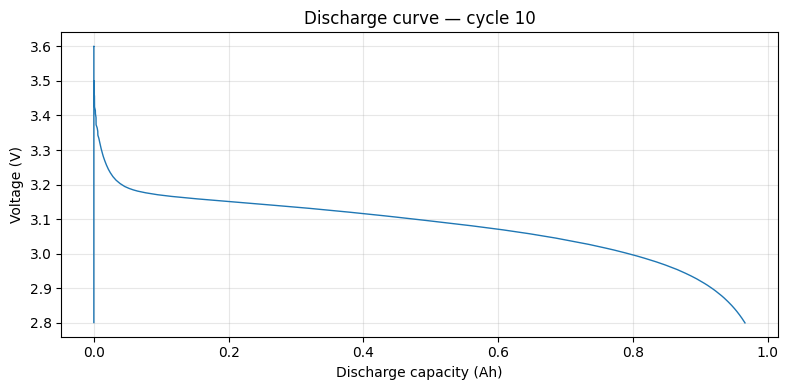

In [10]:
import numpy as np

if curves is not None:
    cycle_to_plot = 10
    idx = np.array(curves['cycle_index']) == cycle_to_plot
    q = np.array(curves['discharge_capacity'])[idx]
    v = np.array(curves['voltage'])[idx]

    print(f'Points in cycle {cycle_to_plot}:', idx.sum())

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(q, v, linewidth=1)
    ax.set_xlabel('Discharge capacity (Ah)')
    ax.set_ylabel('Voltage (V)')
    ax.set_title(f'Discharge curve — cycle {cycle_to_plot}')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Optional — compare two cycles (early vs late)

Severson-style work often uses **voltage curve differences** between early and late cycles (e.g. cycle 10 vs 100). That is Week 3 feature engineering; this is just a preview.

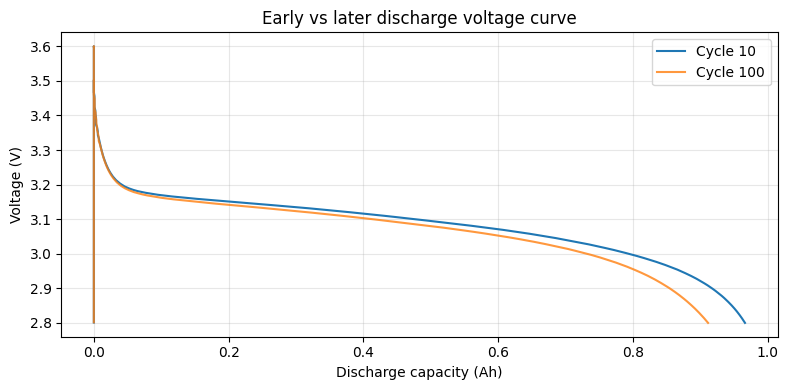

In [11]:
if curves is not None:
    def discharge_curve(df_cycle_index):
        mask = np.array(curves['cycle_index']) == df_cycle_index
        q = np.array(curves['discharge_capacity'])[mask]
        v = np.array(curves['voltage'])[mask]
        return q, v

    q10, v10 = discharge_curve(10)
    q100, v100 = discharge_curve(100)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(q10, v10, label='Cycle 10')
    ax.plot(q100, v100, label='Cycle 100', alpha=0.8)
    ax.set_xlabel('Discharge capacity (Ah)')
    ax.set_ylabel('Voltage (V)')
    ax.legend()
    ax.set_title('Early vs later discharge voltage curve')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8. Takeaways — what to do next

1. Fill in `docs/week01/dataset_description.md` using what you printed above.
2. Next notebook (`03_build_cycle_summary.ipynb`): loop **all** files and save `data/processed/cycle_summary.csv` (one row per cell per cycle).
3. Keep `data/processed/cell_targets.csv` as one row per cell with `EOL` and `initial_capacity`.
4. Do **not** put full `cycles_interpolated` into a CSV yet — it is too large; extract features later.

**Week 1 deliverables:** literature summary + dataset description + problem statement (in `docs/week01/`).